# Exploratory Data Analysis of Video Game Sales
I've always been fascinated by gaming history, so I decided to dig into Kaggle's "Video Game Sales" dataset and see what patterns emerge.
This notebook explores the kaggle dataset "Video Game Sales" which contains over 64,000 video game titles. In this exploration, we'll clean the data, generate descriptive statistics, and find interesting patterns in the data.

## Dataset
As mentioned before, we will be working with the [Kaggle's Video Game Sales Dataset](https://www.kaggle.com/datasets/siddharth0935/video-game-sales?resource=download). For this analysis, we will be using the following columns: 

| Column Name | What it tells us |
| :--- | :--- |
| title | Game title | 
| console | Console the game was released for |
| genre | Genre of the game |
| publisher | Publisher of the game |
| developer | Developer of the game |
| critic_score | Metacritic score (out of 10) |
| total_sales | Global sales of copies in millions |
| na_sales | North American sales of copies in millions |
| jp_sales | Japanese sales of copies in millions |
| pal_sales | European & African sales of copies in millions |
| other_sales | Rest of world sales of copies in millions |
| release_date | Date the game was released on |

We will begin by importing the pandas and numpy libraries and loading the Dataset, for simplicity we will place it in the same folder as the script:

In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv("vgchartz-2024.csv")

In [ ]:
# Checking if the dataset has been loaded correctly by showing the first 5 rows
dataset.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## Data Clean-up
We have succesfully loaded ou dataset, but it might contain some irrelevant or missing data. To start, we won't be using the "img" or the "last_update" columns so we can safely delete them:

In [ ]:
dataset.drop("img", axis = 1, inplace = True)
dataset.drop("last_update", axis = 1, inplace = True)

Now let's check for missing values. It's expected that some games might lack a publisher, a release year, or other details. We could either remove those entries or keep them. For this analysis, we'll keep the rows but replace missing text fields with "Unknown" so we know the data wasn't available. (For numeric columns with missing values, we must handle them separately.)

In [15]:
substituteValues = {'publisher': 'Unknown', 'developer': 'Unknown', 'release_date': 'Unknown'}
dataset.fillna(value=substituteValues, inplace = True)

Now, we are going to work with the missing numeric values. A common approach, for this case, would be to delete the rows with missing numeric data, since they are a very small part of our sample. For this study,
I decided to replace missing values with -1 instead, for a few reasons:

- No game sells negative copies so -1 acts as a clear marker.
- It preserves the rest of the record. 
- It avoids misrepresentation. Filling with 0 would imply the game sold nothing or was rated a 0 by critics,
  which is a different statement entirely.

The only cost for us is that the -1 entries must be excluded before any calculation or visualization that
involves those columns. The goal is to keep the data without letting placeholders
interfere with actual analysis.

In [16]:
substituteValues = {'critic_score': -1, 'total_sales':-1, 'na_sales':-1, 'jp_sales':-1, 'pal_sales':-1, 'other_sales':-1}
dataset.fillna(value=substituteValues, inplace = True)

Another important step in the cleaning up process is to check for exact duplicate rows. We tackled duplicates in two stages.

First, we removed rows that were identical across all columns. We found 21 duplicates this way and removed them, keeping only the first entry. 

In [17]:
print(f"Duplicated rows: {dataset.duplicated().sum()}")
dataset.drop_duplicates(inplace=True)

Duplicated rows: 21


Next, we looked for duplicates based on the combination of title and console.
This is the trickiest part of duplicate removal because the rows share a key but may
differ in other fields like sales figures, year, or publisher. After inspecting a few
cases, we noticed the differences were usually minor (e.g., different publisher and developer names,
missing sales numbers). For the sake of simplicity, we decided to keep the
first occurrence in each group. We acknowledge that this may discard some accurate data
if the first row wasn't the best one, but the impact on high‑level trends should be
negligible for this exploratory study.

In [25]:
dataset.drop_duplicates(subset=['title', 'console'], keep='first', inplace=True)

For entries with complete sales data (no -1 values), we verified that the sum of
regional sales equals `total_sales` within a 0.1M tolerance and found no mismatches.

In [ ]:
sales_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'total_sales']

valid_sales_mask = ~(dataset[sales_cols] == -1).any(axis=1)


dataset_valid = dataset[valid_sales_mask].copy()


regional_sum = (dataset_valid['na_sales'] + dataset_valid['jp_sales'] + 
                dataset_valid['pal_sales'] + dataset_valid['other_sales'])

tolerance = 0.1
mismatch_mask = abs(regional_sum - dataset_valid['total_sales']) > tolerance

print(f"Rows with valid sales data: {len(dataset_valid)}")
print(f"Rows with sales mismatch (>{tolerance}M): {mismatch_mask.sum()}")

if mismatch_mask.sum() > 0:
    print(dataset_valid[mismatch_mask][['title', 'console', 'na_sales', 'jp_sales', 
                                   'pal_sales', 'other_sales', 'total_sales']].head())

Rows with valid sales data: 2221
Rows with sales mismatch (>0.1M): 0


Notice that even though we found no mismatches, we are working with a dataset of over 60.000 entries, we were expecting to see more valid rows than 2221. This means that we must have had a lot of empty values in our sales numbers, which makes sense, since sales numbers per region is not always divulged and some titles may not be released in other regions. This can be verified by running the following code: 

In [31]:
sales_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'total_sales']
for col in sales_cols:
    count = (dataset[col] == -1).sum()
    print(f"{col}: {count} (-1 values)")

na_sales: 51175 (-1 values)
jp_sales: 57101 (-1 values)
pal_sales: 50990 (-1 values)
other_sales: 48685 (-1 values)
total_sales: 44931 (-1 values)


The results show a lot of missing values in our dataset, which calls for a different
approach. As mentioned earlier, some games are released only in specific regions —
so a missing regional sales figure can safely be treated as 0. How do we know which
games are regional? We can assume that if a title has a valid `total_sales`, any
blank regional field simply means the game wasn't sold there. Games without
`total_sales` most likely have undocumented sales numbers and won't be useful for
a sales analysis.

To handle this, we'll create a second dataset called 'sales_dataset' containing only rows
with a valid `total_sales` (and replacing the remaining -1 in regional columns with 0).

In [35]:
sales_dataset = dataset[dataset['total_sales'] != -1].copy()
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
sales_dataset[regional_cols] = sales_dataset[regional_cols].replace(-1, 0)

We can also check if there is a mismatch in the 'total_sales' number with the same code:

In [ ]:
regional_sum = (sales_dataset['na_sales'] + sales_dataset['jp_sales'] + 
                sales_dataset['pal_sales'] + sales_dataset['other_sales'])
mismatch = abs(regional_sum - sales_dataset['total_sales']) > 0.1
print(f"Mismatched rows in sales_dataset: {mismatch.sum()}")

Mismatched rows in sales_dataset: 0


Because sales are reported in millions, a game with tiny sales (e.g., 4,000 copies)
may appear as `0.0` in the dataset. To avoid discarding those low‑selling but real
titles, we only removed rows where all sales columns were exactly `0.0`. These likely represent placeholder entries, not actual games sales.
We found 1343 such rows and deleted them from `sales_dataset`.

In [ ]:
sales_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'total_sales']
all_zero_mask = (sales_dataset[sales_cols] == 0).all(axis=1)

print(f"Titles with 0 in all sales columns: {all_zero_mask.sum()}")


sales_dataset = sales_dataset[~all_zero_mask].copy()

# reseting index
sales_dataset.reset_index(drop=True, inplace=True)

print(f"sales_dataset after removal: {len(sales_dataset)} rows")

Titles with 0 in all sales columns: 1343
sales_dataset after removal: 17517 rows


Our datasets are relatively clean at this point. While we could do a few more cleanups,
they are good enough to start the analysis.

## Game Genre Exploration

With the data cleaned, let's start by understanding the genre landscape. How many
titles fall into each category? Which genres are the most common?

Below is the count of unique genres in the dataset:

In [41]:
genre_counts = dataset['genre'].value_counts()
print(genre_counts)

genre
Misc                9262
Action              8521
Adventure           6247
Role-Playing        5696
Sports              5568
Shooter             5396
Platform            3986
Strategy            3670
Puzzle              3507
Racing              3413
Simulation          3150
Fighting            2363
Action-Adventure    1874
Visual Novel         490
Music                296
Party                151
MMO                  114
Education             34
Board Game            33
Sandbox               20
Name: count, dtype: int64


#### _A Note on Multi-Genre Games_

It’s very common for a game to span multiple genres.
However, in our dataset, each title is assigned to a single genre category. While this
simplifies the analysis, it also means we can't explore hybrid combinations directly.
The `Action-Adventure` genre hints at this overlap, but we'll treat it as its own group
for now. If the dataset included separate tags (e.g., `Action, RPG`), we could split
those into individual labels and analyze co-occurrence patterns.

With that being said, let's return to the analysis.

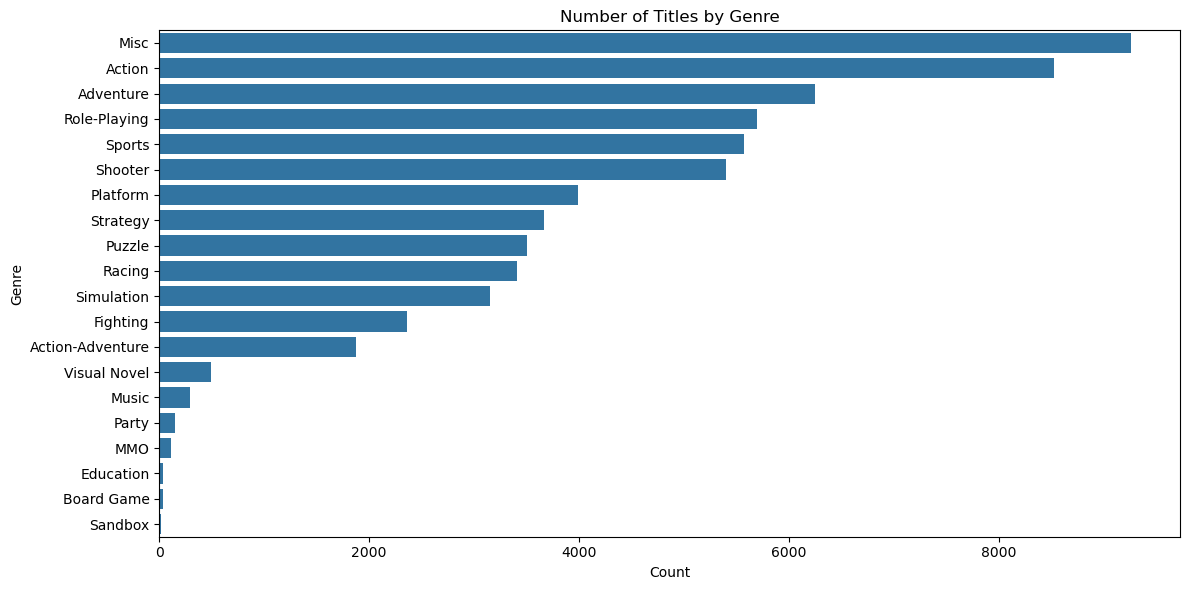

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = dataset['genre'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Number of Titles by Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

From the count and the plot above:
- Misc is the largest category which is likely a catch‑all for games that don't fit neatly in a category. This could mask interesting sub‑trends, but we'll keep it as is for now.
- Action and Adventure dominate the top spots, which aligns with broad market appeal.
- At the tail end, we see niche categories like Education (34) and Sandbox (20).
  These could be grouped into "Other" later if they clutter visualizations.

Above is the genre distribution for the full dataset. The `sales_dataset` tells
a different story: 

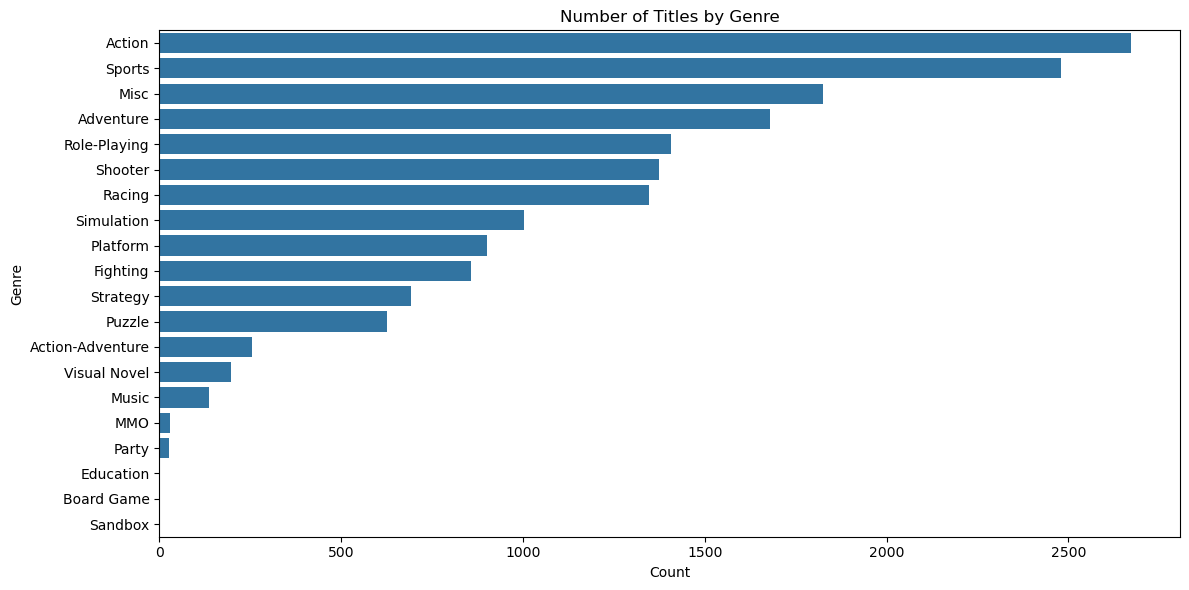

In [45]:
genre_counts = sales_dataset['genre'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Number of Titles by Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [47]:
genre_counts = sales_dataset['genre'].value_counts()
print(genre_counts)

genre
Action              2673
Sports              2479
Misc                1825
Adventure           1680
Role-Playing        1408
Shooter             1374
Racing              1346
Simulation          1003
Platform             901
Fighting             856
Strategy             691
Puzzle               626
Action-Adventure     255
Visual Novel         197
Music                138
MMO                   30
Party                 28
Education              3
Board Game             3
Sandbox                1
Name: count, dtype: int64


These games have well‑documented sales numbers, so we can assume
they represent the more mainstream titles in the catalog. Let's take a look at their
sales figures.

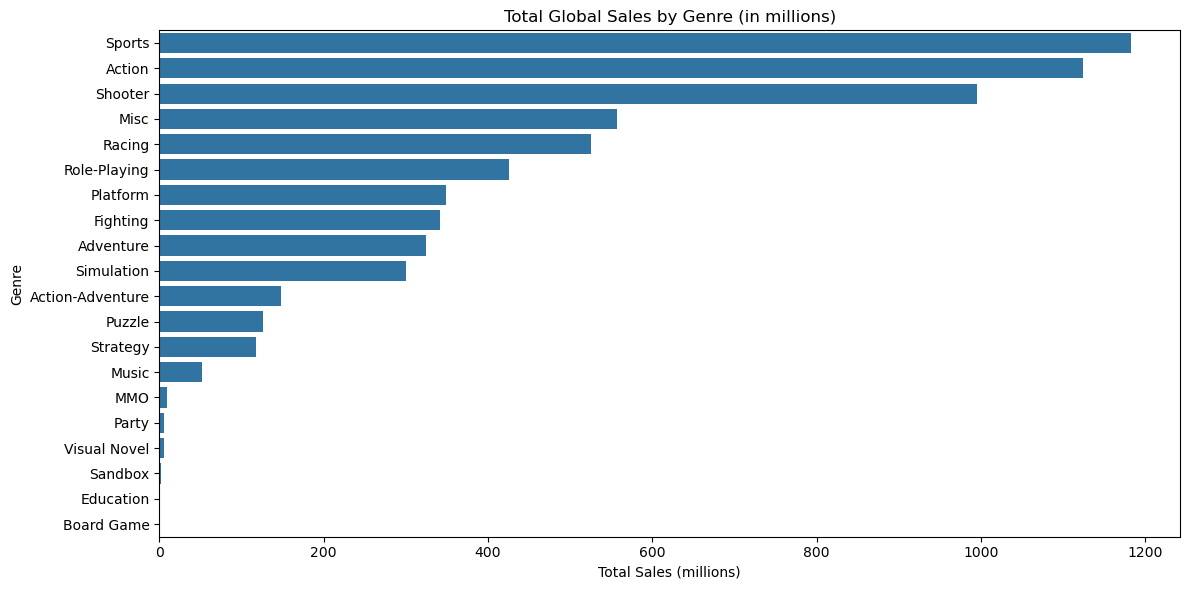

In [52]:
genre_total_sales = sales_dataset.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_total_sales.values, y=genre_total_sales.index)
plt.title('Total Global Sales by Genre (in millions)')
plt.xlabel('Total Sales (millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

Although Action has the most titles, Sports games lead in total sales. Similarly,
the Shooter genre ranks only sixth in number of games, yet moves up to third place
when we look at total copies sold which is a clear sign that genre popularity and commercial
success don't always go hand in hand.

Next, instead of total sales, we'll examine average sales per game by genre.  
This offers a different perspective: which genres tend to give the best return per title?

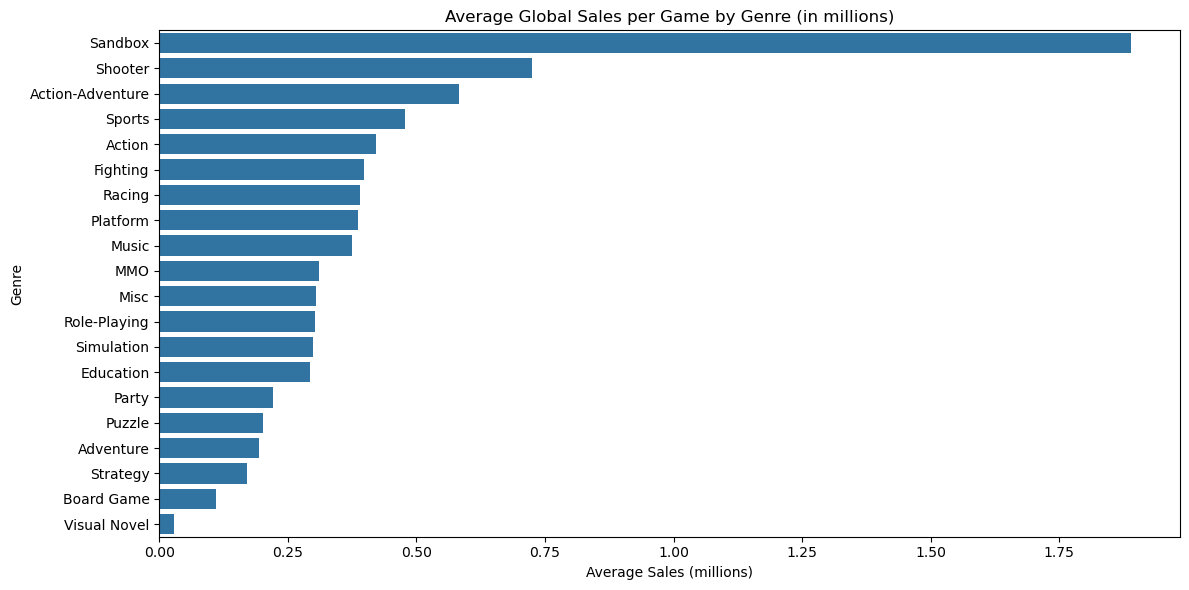

In [54]:
genre_avg_sales = sales_dataset.groupby('genre')['total_sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_avg_sales.values, y=genre_avg_sales.index)
plt.title('Average Global Sales per Game by Genre (in millions)')
plt.xlabel('Average Sales (millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

We only have one game classified as "Sandbox" and it is dominating this comparisson. Let's find which game it is:

In [58]:
print(sales_dataset[sales_dataset['genre']=="Sandbox"])

         title console    genre publisher   developer  critic_score  \
570  Minecraft      NS  Sandbox    Mojang  4J Studios           9.2   

     total_sales  na_sales  jp_sales  pal_sales  other_sales release_date  
570         1.89      0.69      0.52       0.56         0.12   2018-06-21  


Unsurprisingly, it's Minecraft, one of the best‑selling games of all time.
This single title skews the average sales for the entire Sandbox genre.

This highlights an important analytical principle: averages become unreliable when
sample sizes are very small. For genres like Sandbox (1 title), Education (3), or
Board Game (3), we should be careful drawing conclusions. Whenever we compare genres,
it's a good practice to also report how many titles each average is based on.

Speaking of Minecraft, we know that its sales are higher than the 1.89 million listed, which means we either have an incorrect entry or the sales are split in multiple entries. We can check for this by listing every row with the title "Minecraft":

In [77]:
minecraft_entries = sales_dataset[sales_dataset['title'].str.contains('Minecraft', case=False)]
print(minecraft_entries[['title', 'console', 'publisher', 'genre', 'total_sales']])

                                                title console  \
54                                          Minecraft     PS4   
58                                          Minecraft     PS3   
69                                          Minecraft    XOne   
365                                         Minecraft     PSV   
570                                         Minecraft      NS   
848                                         Minecraft    WiiU   
1166                            Minecraft: Story Mode    X360   
1735                            Minecraft: Story Mode     PS3   
1791                            Minecraft: Story Mode     PS4   
2072                            Minecraft: Story Mode    XOne   
3615   Minecraft: Story Mode - The Complete Adventure      NS   
4471                                        Minecraft     3DS   
5772               Minecraft: Story Mode - Season Two    XOne   
9936               Minecraft: Story Mode - Season Two     PS4   
10876              Minecr

So not only does Minecraft appear in multiple rows (one per platform), but many of
those rows also mislabel it as **Misc** instead of **Sandbox**. We can manually fix
these specific entries, but other games may have the same issue, tracking them all
would go beyond the scope of this project. For now, let's correct the Minecraft
entries.

In [78]:
is_minecraft_original = (
    sales_dataset['title'].str.contains('Minecraft', case=False) &
    ~sales_dataset['title'].str.contains('Story|Dungeons|Legends', case=False, regex=True)
)

sales_dataset.loc[is_minecraft_original, 'publisher'] = 'Mojang/Microsoft'
sales_dataset.loc[is_minecraft_original, 'genre'] = 'Sandbox'

In [79]:
minecraft_entries = sales_dataset[sales_dataset['title'].str.contains('Minecraft', case=False)]
print(minecraft_entries[['title', 'console', 'publisher', 'genre', 'total_sales']])

                                                title console  \
54                                          Minecraft     PS4   
58                                          Minecraft     PS3   
69                                          Minecraft    XOne   
365                                         Minecraft     PSV   
570                                         Minecraft      NS   
848                                         Minecraft    WiiU   
1166                            Minecraft: Story Mode    X360   
1735                            Minecraft: Story Mode     PS3   
1791                            Minecraft: Story Mode     PS4   
2072                            Minecraft: Story Mode    XOne   
3615   Minecraft: Story Mode - The Complete Adventure      NS   
4471                                        Minecraft     3DS   
5772               Minecraft: Story Mode - Season Two    XOne   
9936               Minecraft: Story Mode - Season Two     PS4   
10876              Minecr

With that fixed, let's do the previous analysis again:

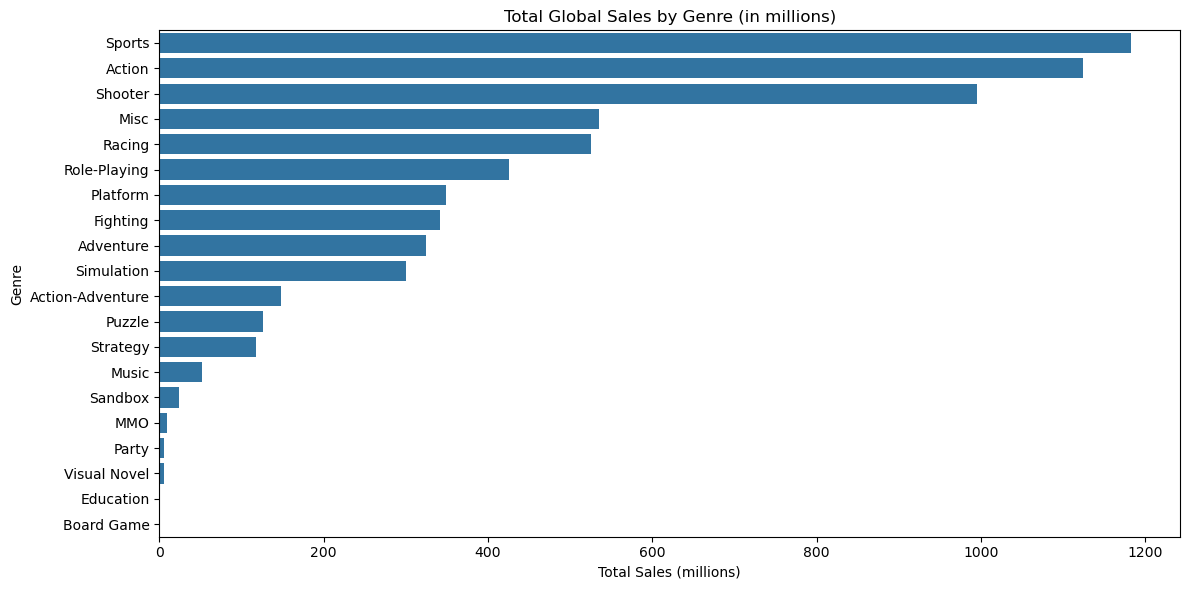

In [81]:
genre_total_sales = sales_dataset.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_total_sales.values, y=genre_total_sales.index)
plt.title('Total Global Sales by Genre (in millions)')
plt.xlabel('Total Sales (millions)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

The Sandbox genre has jumped from 18th place to 15th.
Now let's compare sales by region to see which genres are most popular in each market.

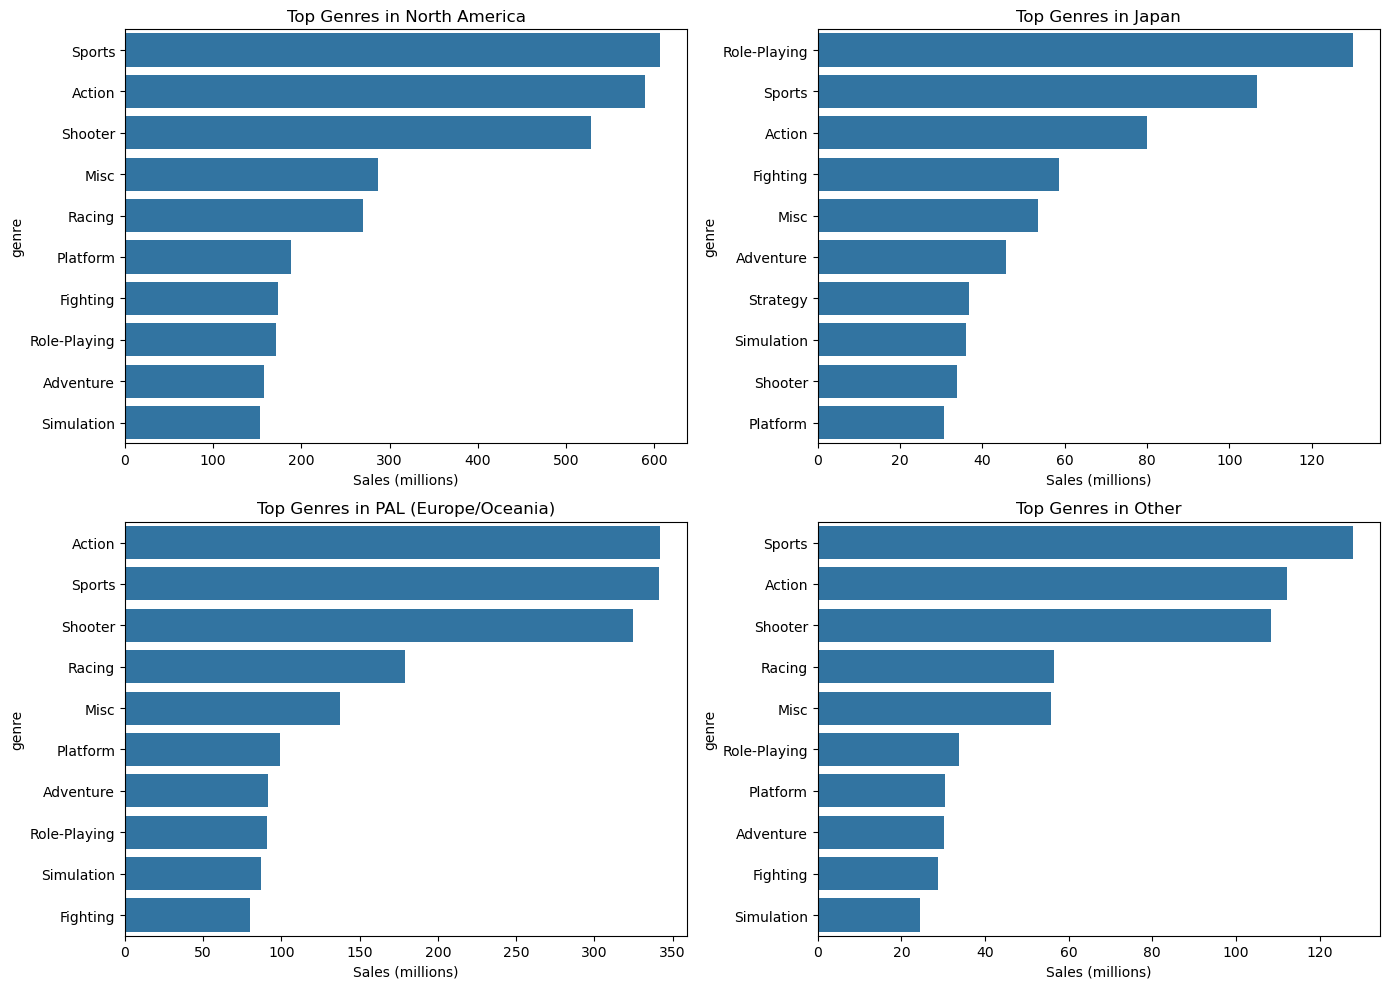

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
regions = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
titles = ['North America', 'Japan', 'PAL (Europe/Oceania)', 'Other']

for ax, region, title in zip(axes.flatten(), regions, titles):
    region_sales = sales_dataset.groupby('genre')[region].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=region_sales.values, y=region_sales.index, ax=ax)
    ax.set_title(f'Top Genres in {title}')
    ax.set_xlabel('Sales (millions)')

plt.tight_layout()
plt.show()

Shooters consistently rank third among the best‑selling genres globally.
Japan is the exception: there, they drop to ninth place, making it the only
market where Role‑Playing games outsell both Sports and Action.

Let's find out the best‑selling game genre per year
and see if any clear trends emerge. We can do this by using a Heatmap:

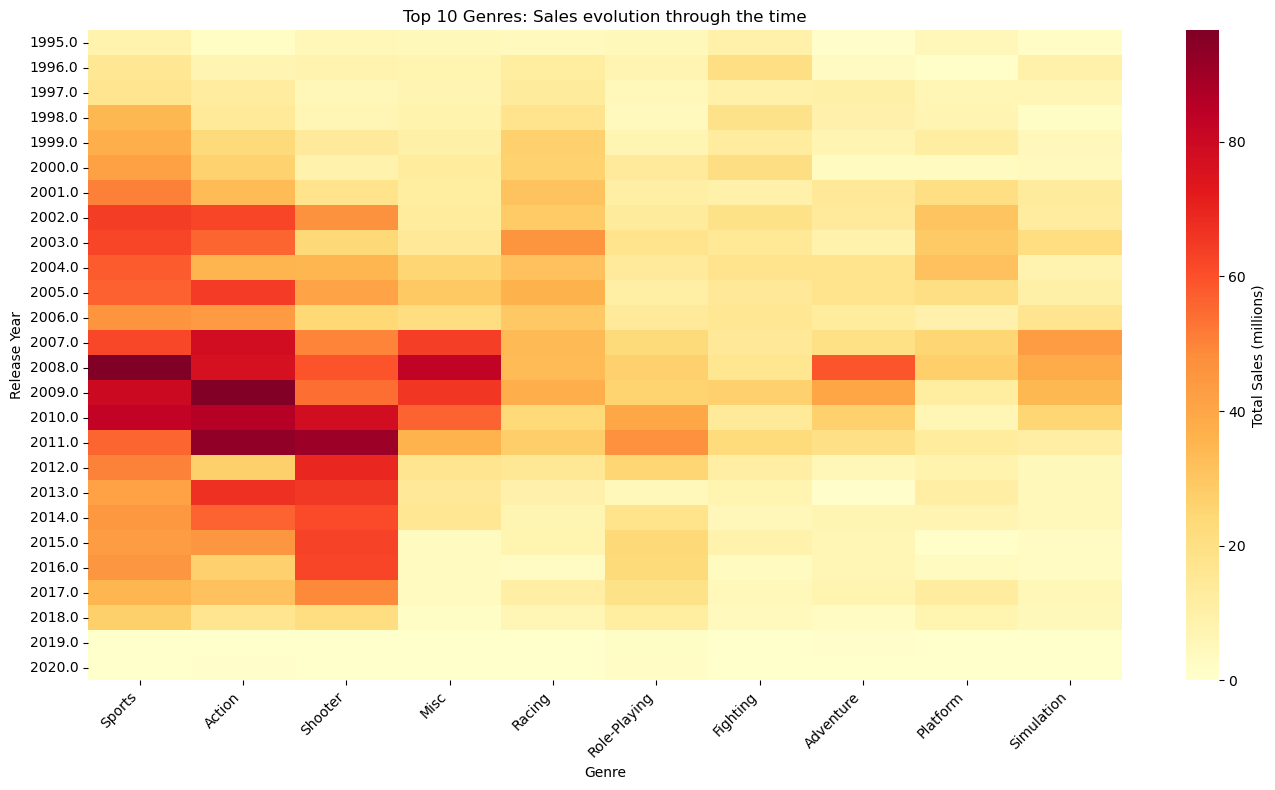

In [88]:
top_genres = df_ano.groupby('genre')['total_sales'].sum().nlargest(10).index

pivot_top = pivot[top_genres]


plt.figure(figsize=(14, 8))
sns.heatmap(pivot_top, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Total Sales (millions)'})
plt.title('Top 10 Genres: Sales evolution through the time')
plt.xlabel('Genre')
plt.ylabel('Release Year')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Wrapping Up

Before we conclude, let's satisfy a bit of curiosity. We've looked at genres,
publishers, and regional tastes. Now, three more questions:

1. What is the most succesful game genre per publisher? 
2. Which individual games sit at the absolute top of the sales charts, and how
   much of the total market do they represent?
3. Which consoles have moved the most software over the years?

In [89]:
pub_genre_sales = sales_dataset.groupby(['publisher', 'genre'])['total_sales'].sum().reset_index()

idx = pub_genre_sales.groupby('publisher')['total_sales'].idxmax()
top_genre_per_pub = pub_genre_sales.loc[idx].reset_index(drop=True)
top_genre_per_pub.columns = ['publisher', 'top_genre', 'genre_total_sales']

merged = sales_dataset.merge(top_genre_per_pub[['publisher', 'top_genre']], 
                             left_on=['publisher', 'genre'], 
                             right_on=['publisher', 'top_genre'])

idx_game = merged.groupby('publisher')['total_sales'].idxmax()
top_game_per_pub = merged.loc[idx_game][['publisher', 'title', 'total_sales']]
top_game_per_pub.columns = ['publisher', 'top_game', 'top_game_sales']

final = top_genre_per_pub.merge(top_game_per_pub, on='publisher')
final = final.sort_values('genre_total_sales', ascending=False)

print(final[['publisher', 'top_genre', 'genre_total_sales', 'top_game', 'top_game_sales']].head(20))

                                  publisher     top_genre  genre_total_sales  \
152                               EA Sports        Sports             444.49   
29                               Activision       Shooter             353.78   
163                         Electronic Arts       Shooter             190.45   
494                          Rockstar Games        Action             167.90   
615                                 Ubisoft        Action             118.06   
6                                 2K Sports        Sports              95.47   
310                                  Konami        Sports              87.64   
564                                     THQ      Fighting              71.63   
82                       Bethesda Softworks  Role-Playing              68.44   
509                                    Sega        Sports              63.13   
322                               LucasArts        Action              59.46   
524             Sony Computer Entertainm

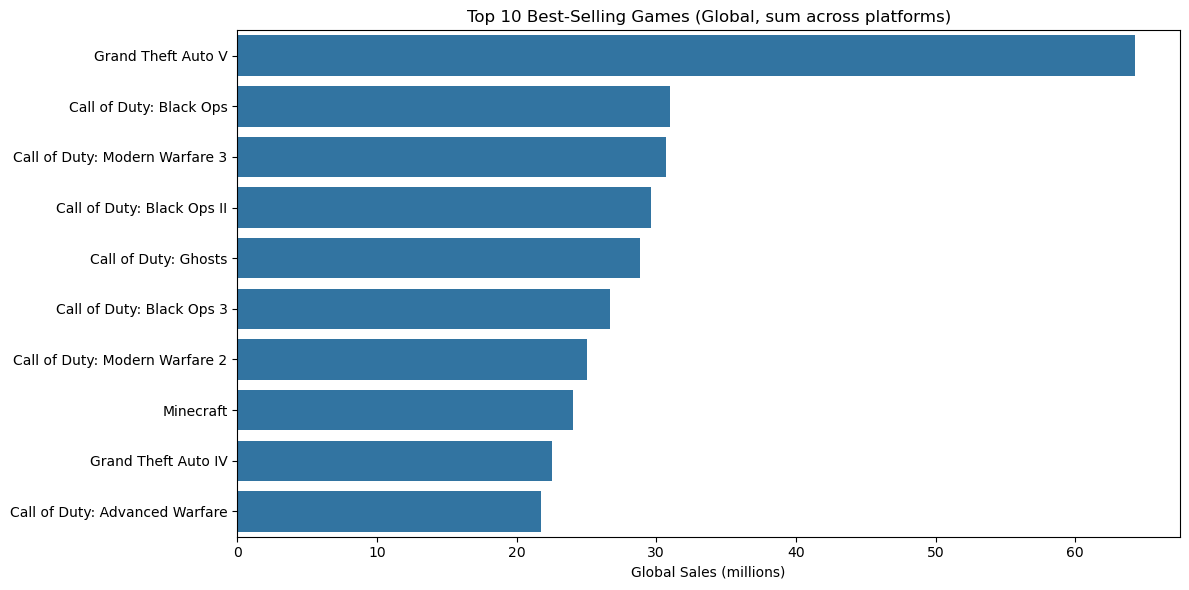

In [ ]:
top10_agg = sales_dataset.groupby('title')['total_sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top10_agg, x='total_sales', y='title')
plt.title('Top 10 Best-Selling Games (Global, sum across platforms)')
plt.xlabel('Global Sales (millions)')
plt.ylabel('')
plt.tight_layout()
plt.show()

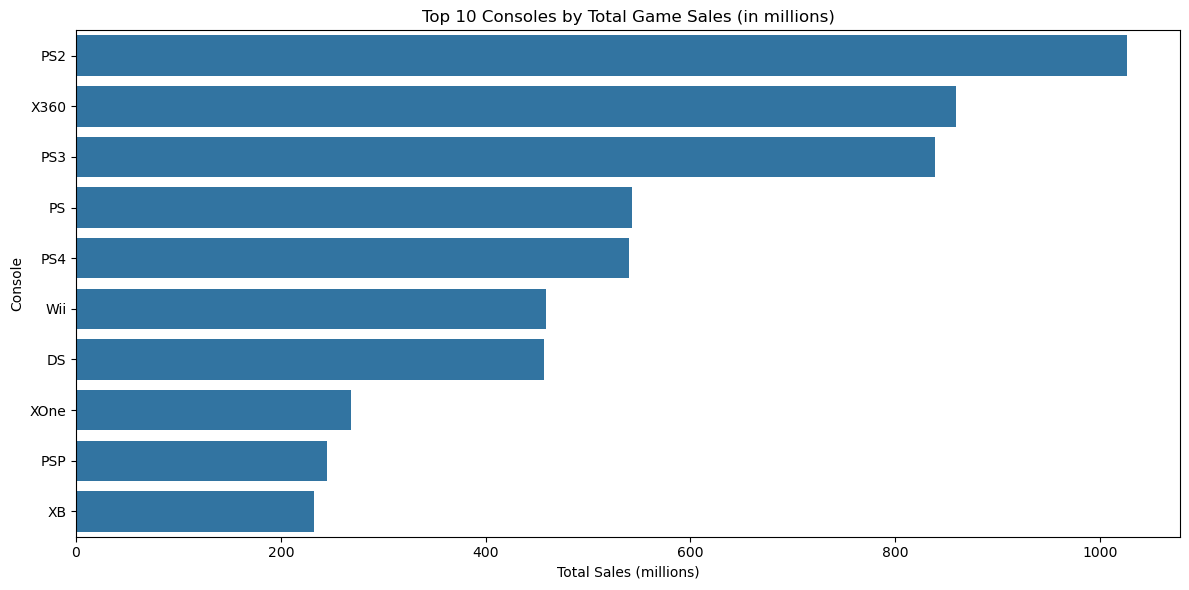

In [ ]:
console_sales = sales_dataset.groupby('console')['total_sales'].sum().sort_values(ascending=False)

top10_consoles = console_sales.head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top10_consoles.values, y=top10_consoles.index)
plt.title('Top 10 Consoles by Total Game Sales (in millions)')
plt.xlabel('Total Sales (millions)')
plt.ylabel('Console')
plt.tight_layout()
plt.show()

### Genre Analysis – Conclusion

Here are the main insights regarding game genres:

- **Sports** leads in total sales, even though it's not the genre with the most titles. This suggests that while there are fewer sports games, they tend to sell exceptionally well, likely due to annual franchises and broad mainstream appeal.

- **Action** has the highest number of titles but ranks second in total sales, indicating a fragmented market with many mediocre‑selling games.

- **Shooter** is an interesting case: sixth in title count, but third in total sales. This reflects the success of blockbuster franchises like *Call of Duty* and *Battlefield*.

- **Role‑Playing** is unique: fifth in both title count and total sales, but it dominates the Japanese market, outselling Sports and Action there.

- **Average sales per game** can be misleading when sample sizes are small. For example, Sandbox (driven by *Minecraft*) shows an inflated average which is a reminder to always check sample sizes.

- The **temporal evolution** (heatmap of top 10 genres) shows that Action and Sports have consistently dominated since the 2000s, while Platform and Fighting have lost market share.

These insights can help guide development and marketing decisions: investing in high‑return genres like Sports or Shooter can be lucrative, but competition is fierce. The Japanese market, however, requires an RPG‑focused strategy.
